In [1]:
import warnings
warnings.filterwarnings('ignore')

import pyreadr
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.semi_supervised import LabelSpreading

In [2]:
result = pyreadr.read_r('listings.RData')
listings = result['listings'].copy()

print('Dimensiones originales:', listings.shape)

listings.head()

Dimensiones originales: (171748, 80)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas"


In [3]:
listings['price_num'] = (
    listings['price']
    .astype(str)
    .str.replace('[$,]', '', regex=True)
)

listings['price_num'] = pd.to_numeric(
    listings['price_num'],
    errors='coerce'
)

features = [
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'minimum_nights',
    'maximum_nights',
    'availability_365',
    'number_of_reviews',
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_location',
    'property_type',
    'room_type'
]

datos = listings[features + ['price_num']].copy()

datos = datos.dropna(subset=['price_num'])

print('Dimensiones luego de seleccionar variables:', datos.shape)


Dimensiones luego de seleccionar variables: (76246, 14)


In [4]:
categoricas = ['property_type', 'room_type']
numericas = [c for c in datos.columns if c not in categoricas + ['price_num']]

for col in categoricas:
    datos[col] = datos[col].fillna('Desconocido')

for col in numericas:
    datos[col] = datos[col].fillna(datos[col].median())

datos = pd.get_dummies(datos, columns=categoricas, drop_first=True)

print('Dimensiones finales:', datos.shape)
datos.head()

Dimensiones finales: (76246, 108)


,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_365,number_of_reviews,review_scores_rating,review_scores_cleanliness,...,property_type_Shipping container,property_type_Tent,property_type_Tiny home,property_type_Tipi,property_type_Tower,property_type_Treehouse,property_type_Yurt,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,3,1.0,1.0,2.0,2,90,328,708,4.85,4.86,...,False,False,False,False,False,False,False,False,False,False
1,2,1.0,1.0,2.0,3,365,316,339,4.97,4.96,...,False,False,False,False,False,False,False,False,False,False
2,2,1.0,1.0,1.0,4,90,88,54,4.57,4.67,...,False,False,False,False,False,False,False,False,False,False
3,3,2.0,2.0,2.0,15,150,321,19,5.00,4.95,...,False,False,False,False,False,False,False,False,False,False
4,2,1.0,1.0,1.0,30,365,211,56,4.95,4.98,...,False,False,False,False,False,False,False,False,False,False


In [5]:

q33 = datos['price_num'].quantile(0.33)
q66 = datos['price_num'].quantile(0.66)

datos['price_category'] = pd.cut(
    datos['price_num'],
    bins=[-np.inf, q33, q66, np.inf],
    labels=['Bajo', 'Medio', 'Alto']
)

datos['price_category'].value_counts()

price_category
Alto     25897
Bajo     25185
Medio    25164
Name: count, dtype: int64

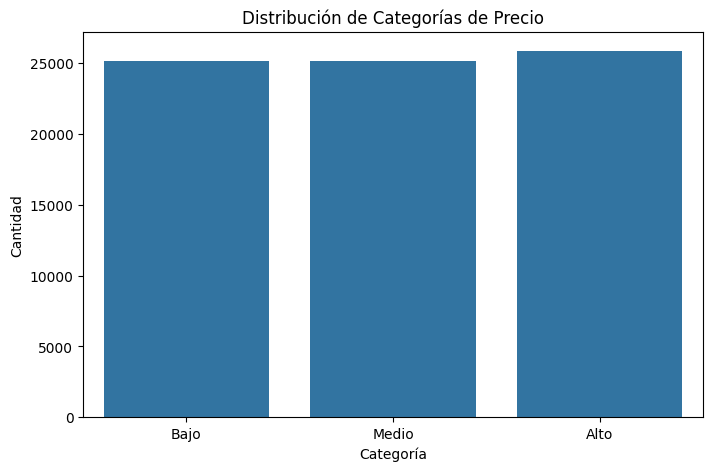

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(x='price_category', data=datos)

plt.title('Distribución de Categorías de Precio')
plt.xlabel('Categoría')
plt.ylabel('Cantidad')

plt.show()


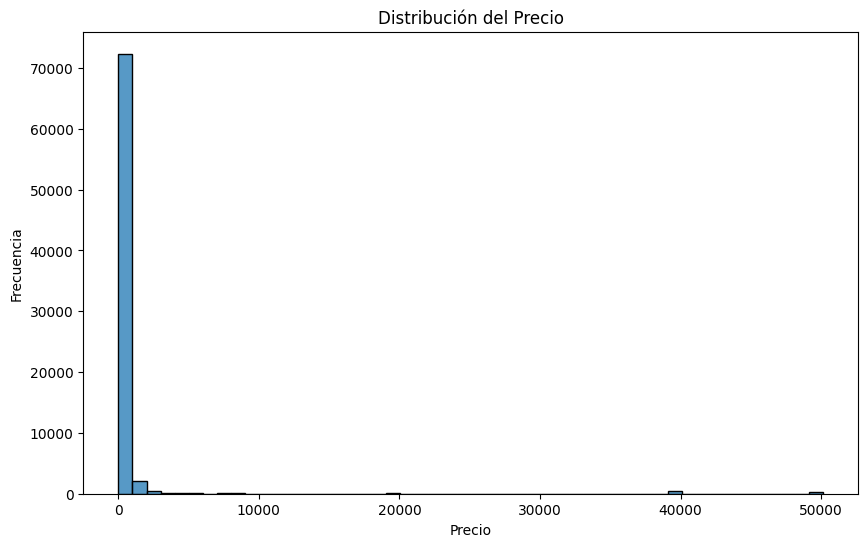

In [7]:

plt.figure(figsize=(10,6))

sns.histplot(datos['price_num'], bins=50)

plt.title('Distribución del Precio')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')

plt.show()

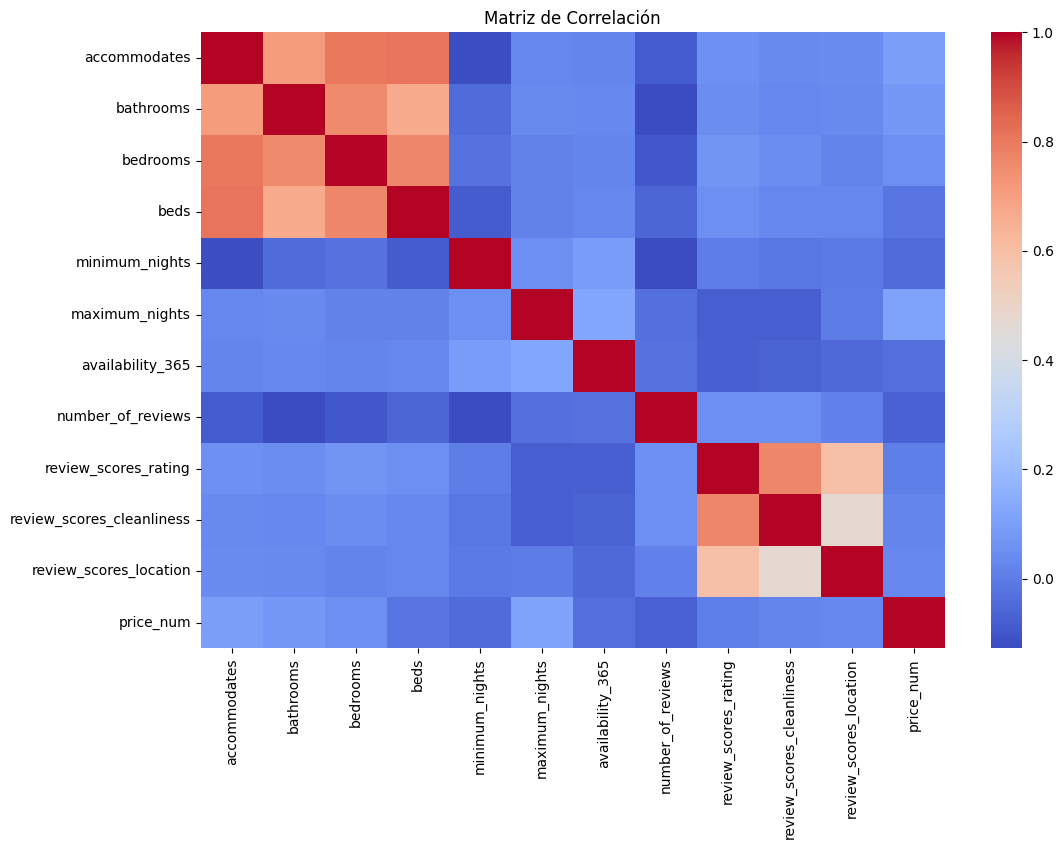

In [8]:

corr = datos[numericas + ['price_num']].corr()

plt.figure(figsize=(12,8))

sns.heatmap(corr, cmap='coolwarm')

plt.title('Matriz de Correlación')

plt.show()

In [ ]:

# Estadísticas descriptivas
print('=== Estadísticas descriptivas ===')
display(datos[numericas + ['price_num']].describe().round(2))

# Boxplots de variables clave por categoría de precio
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
vars_box = ['accommodates', 'bedrooms', 'beds', 'minimum_nights', 'review_scores_rating', 'number_of_reviews']

for ax, var in zip(axes.flatten(), vars_box):
    grupos = [datos[datos['price_category'] == cat][var].dropna() for cat in ['Bajo', 'Medio', 'Alto']]
    ax.boxplot(grupos, labels=['Bajo', 'Medio', 'Alto'])
    ax.set_title(var)
    ax.set_xlabel('Categoría de Precio')

plt.suptitle('Distribución de Variables por Categoría de Precio', fontsize=14)
plt.tight_layout()
plt.show()

# Balance de clases
balance = datos['price_category'].value_counts()
print('\n=== Balance de clases ===')
for cat, count in balance.items():
    print(f'  {cat}: {count} ({count/len(datos)*100:.1f}%)')


In [9]:
X = datos.drop(columns=['price_num', 'price_category'])
y = datos['price_category'].astype(str)

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train:', X_train.shape)
print('Test:', X_test.shape)

Train: (60996, 107)
Test: (15250, 107)


In [10]:
baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

baseline.fit(X_train_scaled, y_train)

pred_baseline = baseline.predict(X_test_scaled)

acc_baseline = accuracy_score(y_test, pred_baseline)
f1_baseline = f1_score(y_test, pred_baseline, average='weighted')

print('Accuracy:', round(acc_baseline, 4))
print('F1 Score:', round(f1_baseline, 4))

Accuracy: 0.6868
F1 Score: 0.6855


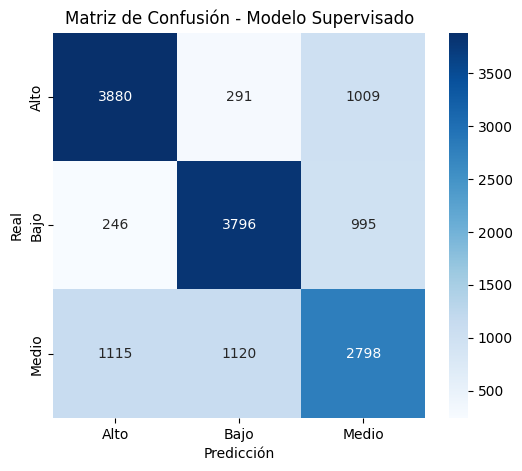

In [11]:
cm = confusion_matrix(y_test, pred_baseline)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title('Matriz de Confusión - Modelo Supervisado')
plt.xlabel('Predicción')
plt.ylabel('Real')

plt.show()

In [ ]:

porcentajes = [0.05, 0.10, 0.20]

resultados = [
    {
        'Modelo': 'Supervisado (baseline)',
        'Porcentaje': 1.0,
        'Accuracy': acc_baseline,
        'F1': f1_baseline
    }
]


In [13]:
for pct in porcentajes:

    X_labeled, X_unlabeled, y_labeled, y_unlabeled = train_test_split(
        X_train_scaled,
        y_train,
        train_size=pct,
        random_state=42,
        stratify=y_train
    )

    y_semi = np.copy(y_train)

    mask = np.ones(len(y_train), dtype=bool)
    mask[:len(y_labeled)] = False

    np.random.shuffle(mask)

    y_semi[mask] = -1

    base_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    self_training = SelfTrainingClassifier(
        base_model,
        threshold=0.8
    )

    self_training.fit(X_train_scaled, y_semi)

    pred = self_training.predict(X_test_scaled)

    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average='weighted')

    resultados.append({
        'Modelo': 'SelfTraining',
        'Porcentaje': pct,
        'Accuracy': acc,
        'F1': f1
    })

    print('Porcentaje etiquetado:', pct)
    print('Accuracy:', round(acc,4))
    print('F1:', round(f1,4))
    print()

Porcentaje etiquetado: 0.05
Accuracy: 0.621
F1: 0.5869

Porcentaje etiquetado: 0.1
Accuracy: 0.6386
F1: 0.6172

Porcentaje etiquetado: 0.2
Accuracy: 0.6557
F1: 0.6424



In [ ]:

# ── LabelSpreading: segundo algoritmo semisupervisado ──────────────────────────
# Se usa submuestra (N=10000) por eficiencia del grafo k-NN
N_SUBSAMPLE = 10000
rng = np.random.RandomState(42)
idx_sub = rng.choice(len(X_train_scaled), size=N_SUBSAMPLE, replace=False)
X_sub = X_train_scaled[idx_sub]
y_sub = y_train[idx_sub]

print('=== LabelSpreading ===')
for pct in porcentajes:
    n_labeled = max(int(N_SUBSAMPLE * pct), 3)

    y_semi_ls = np.full(N_SUBSAMPLE, -1)
    idx_labeled = rng.choice(N_SUBSAMPLE, size=n_labeled, replace=False)
    y_semi_ls[idx_labeled] = y_sub[idx_labeled]

    ls = LabelSpreading(kernel='knn', n_neighbors=7, max_iter=200, alpha=0.2)
    ls.fit(X_sub, y_semi_ls)
    pred = ls.predict(X_test_scaled)

    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average='weighted')

    resultados.append({
        'Modelo': 'LabelSpreading',
        'Porcentaje': pct,
        'Accuracy': acc,
        'F1': f1
    })

    print(f'Porcentaje etiquetado: {pct}')
    print(f'Accuracy: {round(acc, 4)}')
    print(f'F1: {round(f1, 4)}')
    print()


In [ ]:

# ── Variación de hiperparámetros: SelfTraining (threshold) ────────────────────
print('=== SelfTraining: sensibilidad al threshold (10% etiquetados) ===')
thresholds = [0.6, 0.7, 0.8, 0.9]
resultados_thresh = []

n_labeled_st = int(len(y_train) * 0.10)
y_semi_st = np.full(len(y_train), -1)
idx_st = np.random.RandomState(42).choice(len(y_train), size=n_labeled_st, replace=False)
y_semi_st[idx_st] = y_train[idx_st]

for thresh in thresholds:
    base = RandomForestClassifier(n_estimators=100, random_state=42)
    st = SelfTrainingClassifier(base, threshold=thresh)
    st.fit(X_train_scaled, y_semi_st)
    pred = st.predict(X_test_scaled)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average='weighted')
    resultados_thresh.append({'Threshold': thresh, 'Accuracy': acc, 'F1': f1})
    print(f'threshold={thresh} → Accuracy={round(acc,4)}, F1={round(f1,4)}')

df_thresh = pd.DataFrame(resultados_thresh)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df_thresh['Threshold'], df_thresh['Accuracy'], marker='o', color='steelblue')
axes[0].set_title('SelfTraining: Accuracy vs Threshold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Accuracy')
axes[0].grid(True)

axes[1].plot(df_thresh['Threshold'], df_thresh['F1'], marker='o', color='coral')
axes[1].set_title('SelfTraining: F1 vs Threshold')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:

# ── Variación de hiperparámetros: LabelSpreading (n_neighbors) ─────────────────
print('=== LabelSpreading: sensibilidad a n_neighbors (10% etiquetados) ===')
n_neighbors_list = [3, 5, 7, 10, 15]
resultados_nn = []

n_labeled_ls_hp = max(int(N_SUBSAMPLE * 0.10), 3)
y_semi_ls_hp = np.full(N_SUBSAMPLE, -1)
idx_ls_hp = np.random.RandomState(42).choice(N_SUBSAMPLE, size=n_labeled_ls_hp, replace=False)
y_semi_ls_hp[idx_ls_hp] = y_sub[idx_ls_hp]

for nn in n_neighbors_list:
    ls = LabelSpreading(kernel='knn', n_neighbors=nn, max_iter=200, alpha=0.2)
    ls.fit(X_sub, y_semi_ls_hp)
    pred = ls.predict(X_test_scaled)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average='weighted')
    resultados_nn.append({'n_neighbors': nn, 'Accuracy': acc, 'F1': f1})
    print(f'n_neighbors={nn} → Accuracy={round(acc,4)}, F1={round(f1,4)}')

df_nn = pd.DataFrame(resultados_nn)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df_nn['n_neighbors'], df_nn['Accuracy'], marker='o', color='steelblue')
axes[0].set_title('LabelSpreading: Accuracy vs n_neighbors')
axes[0].set_xlabel('n_neighbors')
axes[0].set_ylabel('Accuracy')
axes[0].grid(True)

axes[1].plot(df_nn['n_neighbors'], df_nn['F1'], marker='o', color='coral')
axes[1].set_title('LabelSpreading: F1 vs n_neighbors')
axes[1].set_xlabel('n_neighbors')
axes[1].set_ylabel('F1 Score')
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:

# ── Matrices de confusión: mejores modelos semisupervisados (20% etiquetados) ──
# SelfTraining
n_lab_20 = int(len(y_train) * 0.20)
y_semi_cm = np.full(len(y_train), -1)
idx_cm = np.random.RandomState(42).choice(len(y_train), size=n_lab_20, replace=False)
y_semi_cm[idx_cm] = y_train[idx_cm]

st_best = SelfTrainingClassifier(
    RandomForestClassifier(n_estimators=100, random_state=42), threshold=0.8
)
st_best.fit(X_train_scaled, y_semi_cm)
pred_st_best = st_best.predict(X_test_scaled)

# LabelSpreading
n_lab_ls_20 = max(int(N_SUBSAMPLE * 0.20), 3)
y_semi_ls_cm = np.full(N_SUBSAMPLE, -1)
idx_ls_cm = np.random.RandomState(42).choice(N_SUBSAMPLE, size=n_lab_ls_20, replace=False)
y_semi_ls_cm[idx_ls_cm] = y_sub[idx_ls_cm]

ls_best = LabelSpreading(kernel='knn', n_neighbors=7, max_iter=200, alpha=0.2)
ls_best.fit(X_sub, y_semi_ls_cm)
pred_ls_best = ls_best.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pred, title in zip(
    axes,
    [pred_st_best, pred_ls_best],
    ['SelfTraining (threshold=0.8, 20%)', 'LabelSpreading (n_neighbors=7, 20%)']
):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=encoder.classes_,
                yticklabels=encoder.classes_, ax=ax)
    ax.set_title(f'Matriz de Confusión\n{title}')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()


In [ ]:

# ── Curvas de desempeño: % etiquetados vs accuracy/F1 ─────────────────────────
df_resultados = pd.DataFrame(resultados)
df_semi = df_resultados[df_resultados['Modelo'] != 'Supervisado (baseline)'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores = {'SelfTraining': 'steelblue', 'LabelSpreading': 'coral'}

for modelo, grp in df_semi.groupby('Modelo'):
    axes[0].plot(grp['Porcentaje'] * 100, grp['Accuracy'],
                 marker='o', label=modelo, color=colores.get(modelo, 'gray'))
    axes[1].plot(grp['Porcentaje'] * 100, grp['F1'],
                 marker='o', label=modelo, color=colores.get(modelo, 'gray'))

for ax, val, metric in zip(axes, [acc_baseline, f1_baseline], ['Accuracy', 'F1']):
    ax.axhline(y=val, color='red', linestyle='--', label='Supervisado (baseline)')
    ax.set_xlabel('% Datos Etiquetados')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} vs % de Datos Etiquetados')
    ax.legend()
    ax.grid(True)

plt.suptitle('Curvas de Desempeño: Supervisado vs Semisupervisado', fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:

# ── Comparación final ──────────────────────────────────────────────────────────
df_resultados = pd.DataFrame(resultados)
print('=== Tabla Comparativa de Resultados ===')
display(df_resultados.sort_values('Accuracy', ascending=False).round(4))

palette = {
    'Supervisado (baseline)': 'red',
    'SelfTraining': 'steelblue',
    'LabelSpreading': 'coral'
}
df_resultados['Label'] = df_resultados.apply(
    lambda r: f"{r['Modelo']}\n({int(r['Porcentaje']*100)}%)", axis=1
)
colors = [palette.get(m, 'gray') for m in df_resultados['Modelo']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ['Accuracy', 'F1']):
    bars = ax.bar(df_resultados['Label'], df_resultados[metric], color=colors)
    ax.set_title(f'{metric} por Modelo')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, df_resultados[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Comparación Final de Modelos', fontsize=13)
plt.tight_layout()
plt.show()
